# DefAn: Regression Pipeline for Hallucination Probability

Predicts continuous hallucination probability $p_i$ instead of binary label.
Includes grid search, AdaBoost, binary vs regression comparison,
and cross-dataset generalization to MMLU, TriviaQA, and TruthfulQA.


## Setup

In [25]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')

from hallucination_utils import *
from regression_utils import *
import xgboost as xgb
import shap

print('All imports loaded.')


All imports loaded.


## Configuration

In [26]:
DATA_PATH = './data/defan_t0.9_n20.jsonl'
OUTPUT_DIR = 'defan_regression_output'
EMBED_CACHE = 'defan_embeddings.npy'
SIM_THRESHOLD = 0.85
N_BOOTSTRAP = 2000
RANDOM_SEED = 42
MIN_QUESTIONS_FOR_ANALYSIS = 10
TEST_FRACTION = 0.15
VAL_FRACTION = 0.15

os.makedirs(OUTPUT_DIR, exist_ok=True)
np.random.seed(RANDOM_SEED)


## Load Data, Embed, Extract Features

In [27]:
df = load_dataset('./data/defan_t0.9_n20.jsonl')
df = add_canonical_domain(df)
print_loading_summary(df)


Dataset:          defan
Total rows:       10000
Unique questions: 500
Samples/question: min=20, max=20, median=20.0

Correctness distribution:
  correct     :   2377  (23.8%)
  incorrect   :   7621  (76.2%)
  refused     :      2  (0.0%)

Domains (7 unique):
  Humanities
  Law, Business, and Miscellaneous
  Medicine & Health
  STEM
  Science & Technology
  Social Sciences
  Sports

Answer types: ['city', 'date', 'name', 'numeric']


In [28]:
all_embeddings = embed_responses(df, cache_path='defan_embeddings.npy')
mu_ref, cov_inv = fit_reference_distribution(all_embeddings, df)
feat_df, skipped, skip_det = extract_question_features(
    df, all_embeddings, mu_ref, cov_inv, domain_col='domain_canonical')
feat_df.to_csv(os.path.join(OUTPUT_DIR, 'defan_features.csv'), index=False)


# Ensure regression target column exists (backward compat)
ensure_p_halluc(feat_df)

Loading cached embeddings from defan_embeddings.npy
Correct responses for reference: 2377
Reference fitted. mu shape: (384,), precision shape: (384, 384)
  500/500 ...

Questions processed: 500
Questions skipped (all refused): 0
Label distribution:
  Correct (0): 102
  Hallucinated (1): 398
  Rate: 79.6%


,prompt_id,question,domain_canonical,domain_inconsistent,adversarial,n_samples,n_correct,n_incorrect,n_refused,n_definitive,...,score_std,len_mean,len_std,H_sem,D_cos,M_bar,K,sig2_S,label,type
0,q_000,Who claimed the championship title in the 1950...,Humanities,False,False,20,13,7,0,20,...,1.907878,19.75,19.999687,3.001609,0.217717,18.886183,11,0.045926,0,name
1,q_001,Which nation secured the second position in th...,Humanities,False,False,20,0,20,0,20,...,0.217945,48.30,28.721246,2.921928,0.281187,30.100367,11,0.073850,1,name
2,q_002,What was the crowd size at the final match of ...,Humanities,True,False,20,0,20,0,20,...,0.357071,47.85,24.054677,4.121928,0.339244,45.852200,18,0.026550,1,numeric
3,q_003,Which team emerged victorious in the 1994 FIFA...,Humanities,False,False,20,15,5,0,20,...,1.732051,9.30,11.410960,1.076298,0.097322,8.284129,3,0.041397,0,name
4,q_004,In which stadium did the climax of the 1938 FI...,Humanities,False,False,20,2,18,0,20,...,1.203121,33.85,16.322607,3.446439,0.306600,37.692467,14,0.037540,1,name
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,q_495,"In 2021, where was CVPR hosted?",STEM,False,False,20,2,18,0,20,...,1.194780,73.90,32.654096,3.684184,0.295112,34.011993,14,0.062270,1,city
496,q_496,What location accommodated CVPR in 1997?,STEM,False,False,20,0,20,0,20,...,0.500000,24.90,15.032964,3.721928,0.335266,41.490444,15,0.053943,1,city
497,q_497,Where was the venue for CVPR in 2012?,STEM,False,False,20,0,20,0,20,...,0.458258,49.65,30.561863,4.121928,0.426996,41.229836,18,0.038741,1,city
498,q_498,"In 2008, where was CVPR held?",STEM,False,False,20,0,20,0,20,...,0.458258,60.10,25.888028,3.621928,0.355751,36.549568,14,0.057942,1,city


## Regression Target EDA

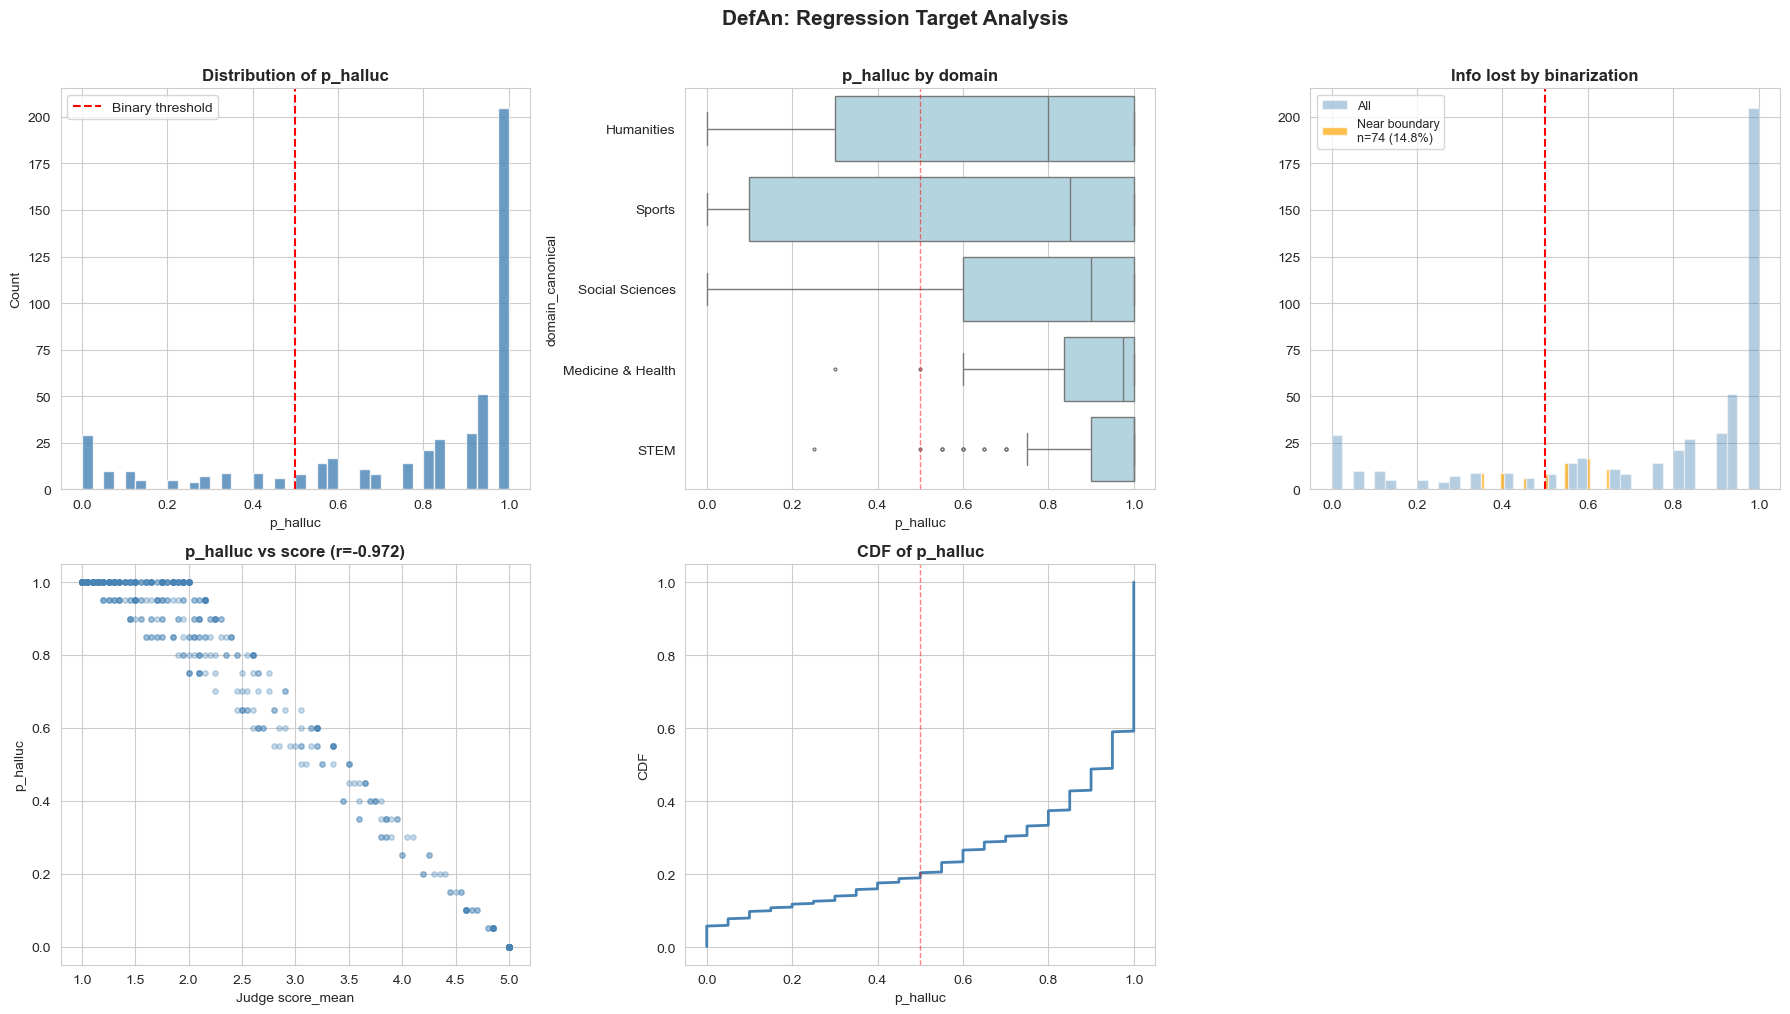

In [29]:
fig = plot_target_eda(feat_df, domain_col='domain_canonical', title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_target_eda.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This is the main target-distribution EDA figure for the continuous regression label $p_{\rm halluc}$. Its role is to show how hallucination probability is distributed overall, and likely also how it varies across domains. It is useful because this notebook is no longer predicting a hard binary label only; instead it models a continuous risk score, so this figure tells you whether the target is concentrated near 0 or 1 or whether there is meaningful intermediate structure to learn.

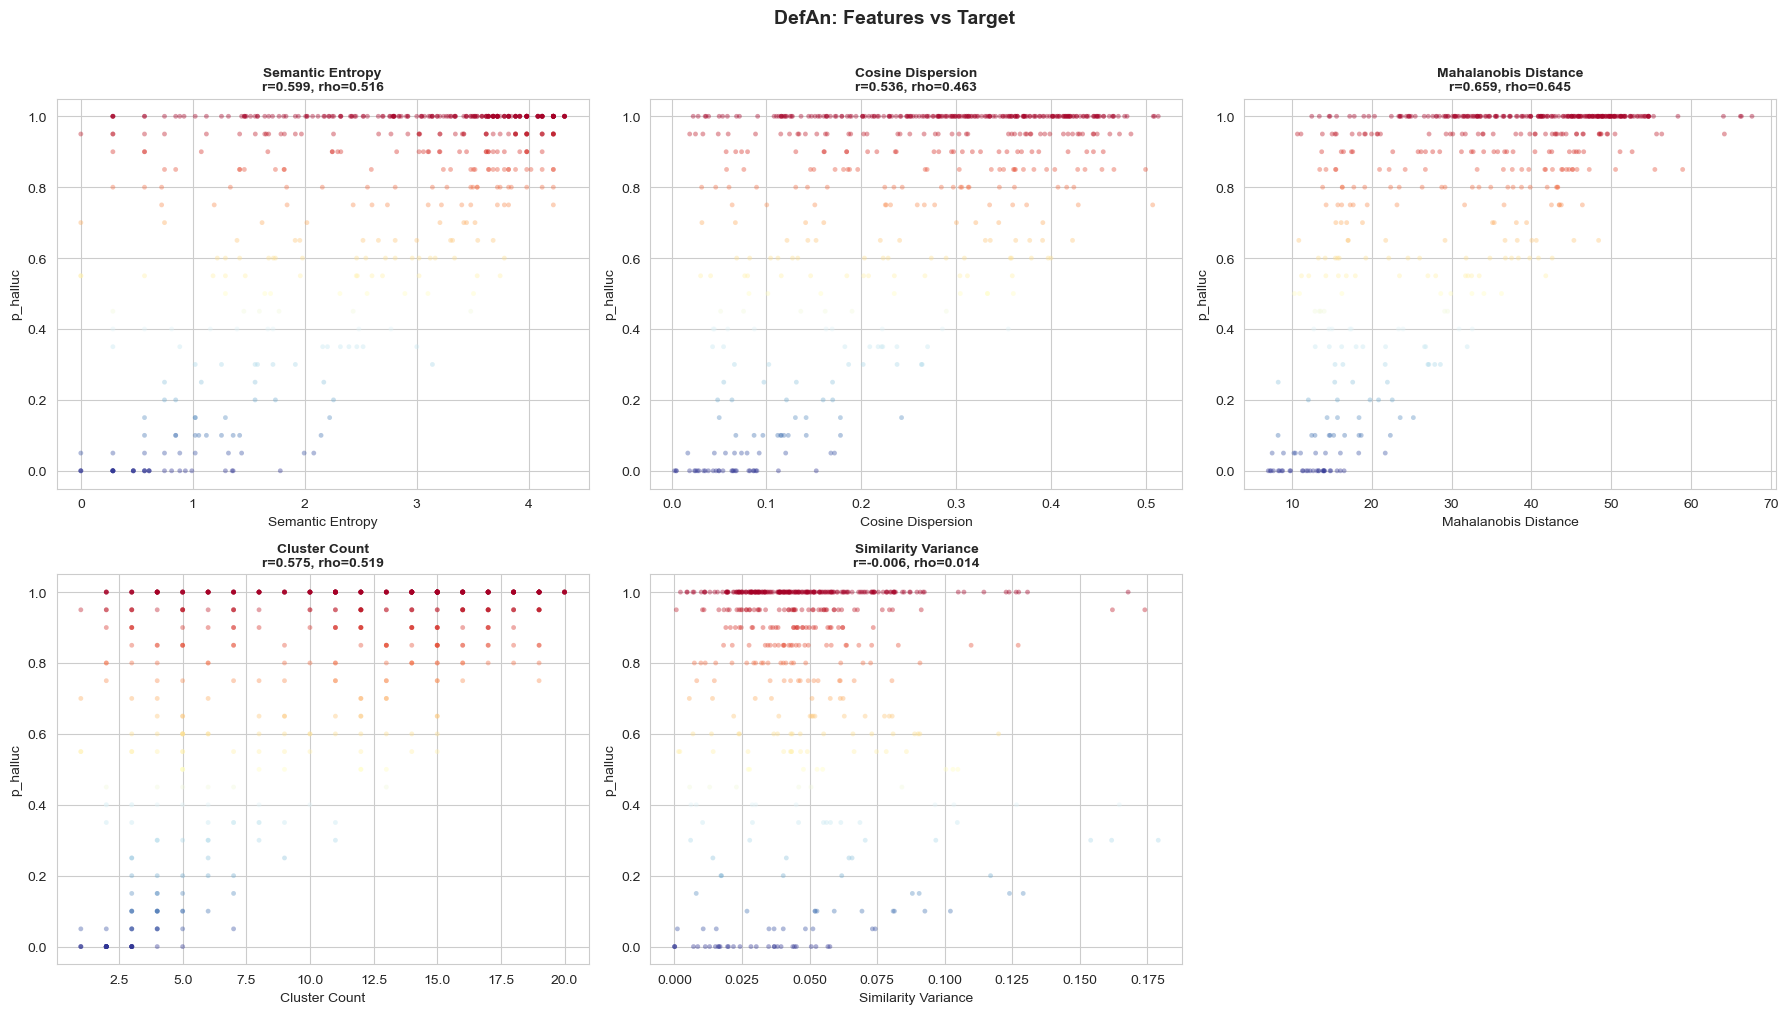

In [30]:
fig = plot_features_vs_target(feat_df, title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_features_vs_target.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This figure relates the geometric features to the continuous hallucination probability rather than the binary label.

### Pearson correlation
The **Pearson correlation coefficient** measures the strength and direction of a **linear relationship** between two variables.  
It ranges from **-1 to +1**:
- **+1**: perfect positive linear correlation
- **0**: no linear correlation
- **-1**: perfect negative linear correlation

Pearson correlation is most appropriate when the relationship is approximately linear and the variables are continuous.

### Spearman correlation
The **Spearman rank correlation coefficient** measures the strength and direction of a **monotonic relationship** between two variables using their ranks rather than their raw values.  
It also ranges from **-1 to +1**:
- **+1**: perfect increasing monotonic relationship
- **0**: no monotonic relationship
- **-1**: perfect decreasing monotonic relationship

Spearman correlation is useful when the relationship may be nonlinear but still monotonic, or when the data contain outliers or are not normally distributed.

### Significance of the correlation
The **significance** of a correlation is assessed using its **p-value**, which tests the null hypothesis that the true correlation is zero.

- A **small p-value** (commonly **p < 0.05**) suggests that the observed correlation is unlikely to have occurred by chance.
- A **large p-value** suggests that the data do not provide strong evidence for a real association.

In practice:
- the **correlation coefficient** tells you **how strong** the relationship is,
- the **p-value** tells you **how statistically convincing** that relationship is.

## Train / Validation / Test Split

In [31]:
sp = split_train_val_test(feat_df, GEO_FEATURES,
                          test_frac=TEST_FRACTION, val_frac=VAL_FRACTION,
                          seed=RANDOM_SEED)
print_split_summary(sp)


  Train: n= 350  p_halluc mean=0.7650 std=0.3221  binary rate=0.794
  Val  : n=  75  p_halluc mean=0.7627 std=0.3065  binary rate=0.800
  Test : n=  75  p_halluc mean=0.7493 std=0.3313  binary rate=0.800


### Grid Search

We run grid search on models that support it to find optimal hyperparameters
before the main evaluation.


In [32]:
print('Running grid search on training set...')
regressors = get_regressors(seed=RANDOM_SEED)
regressors, df_grid = run_grid_search(regressors, sp['X_train_sc'], sp['y_train_reg'],
                                       seed=RANDOM_SEED, cv_folds=5)
if len(df_grid) > 0:
    display(df_grid)
    df_grid.to_csv(os.path.join(OUTPUT_DIR, 'grid_search_results.csv'), index=False)
print('Grid search complete. Models updated with best params.')


Running grid search on training set...
  Ridge               : searching {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]} ...
    -> best: {'alpha': 0.1}  CV r2=0.4767
  Lasso               : searching {'alpha': [0.001, 0.005, 0.01, 0.05, 0.1]} ...
    -> best: {'alpha': 0.001}  CV r2=0.4753
  ElasticNet          : searching {'alpha': [0.005, 0.01, 0.05, 0.1], 'l1_ratio': [0.2, 0.5, 0.8]} ...
    -> best: {'alpha': 0.005, 'l1_ratio': 0.2}  CV r2=0.4742
  Random Forest       : searching {'n_estimators': [100, 300], 'max_depth': [4, 6, 8]} ...
    -> best: {'max_depth': 4, 'n_estimators': 300}  CV r2=0.5044
  XGBoost             : searching {'n_estimators': [100, 300], 'max_depth': [3, 4, 5], 'learning_rate': [0.05, 0.08, 0.1]} ...
    -> best: {'learning_rate': 0.08, 'max_depth': 4, 'n_estimators': 100}  CV r2=0.5059
  SVR (RBF)           : no grid defined, skipping
  AdaBoost            : searching {'n_estimators': [100, 200, 300], 'learning_rate': [0.05, 0.1, 0.3]} ...
    -> best: {'learning

,Model,Best_Params,Best_CV_Score
0,Ridge,{'alpha': 0.1},0.476666
1,Lasso,{'alpha': 0.001},0.475284
2,ElasticNet,"{'alpha': 0.005, 'l1_ratio': 0.2}",0.474233
3,Random Forest,"{'max_depth': 4, 'n_estimators': 300}",0.504418
4,XGBoost,"{'learning_rate': 0.08, 'max_depth': 4, 'n_est...",0.505869
5,AdaBoost,"{'learning_rate': 0.05, 'n_estimators': 200}",0.502816


Grid search complete. Models updated with best params.


## Regression Models — Evaluation

In [33]:
df_reg, fitted_regs = train_evaluate_regressors(regressors, sp, seed=RANDOM_SEED)
df_reg.to_csv(os.path.join(OUTPUT_DIR, 'regression_results.csv'), index=False)
display(df_reg.round(4))


  Ridge                | CV R²=0.5138  Val R²=0.5044  Test R²=0.3475  Gap=+0.0272
  Lasso                | CV R²=0.5123  Val R²=0.4968  Test R²=0.3539  Gap=+0.0338
  ElasticNet           | CV R²=0.5113  Val R²=0.4921  Test R²=0.3570  Gap=+0.0373
  Random Forest        | CV R²=0.5424  Val R²=0.5616  Test R²=0.4075  Gap=+0.1690
  XGBoost              | CV R²=0.5434  Val R²=0.6203  Test R²=0.3959  Gap=+0.3068
  SVR (RBF)            | CV R²=0.5709  Val R²=0.6161  Test R²=0.4439  Gap=+0.0262
  AdaBoost             | CV R²=0.5361  Val R²=0.5592  Test R²=0.4454  Gap=+0.1910


,Model,CV_R2,CV_MSE,CV_MAE,Train_R2,Val_R2,Val_MSE,Val_MAE,Test_R2,Test_MSE,Test_MAE,Test_Pearson_r,Overfit_Gap_Val,Overfit_Gap_Test
0,Ridge,0.5138,0.0504,0.1735,0.5316,0.5044,0.0466,0.1650,0.3475,0.0716,0.2054,0.5981,0.0272,0.1841
1,Lasso,0.5123,0.0506,0.1741,0.5307,0.4968,0.0473,0.1680,0.3539,0.0709,0.2052,0.6020,0.0338,0.1768
2,ElasticNet,0.5113,0.0507,0.1744,0.5294,0.4921,0.0477,0.1696,0.3570,0.0706,0.2054,0.6038,0.0373,0.1724
3,Random Forest,0.5424,0.0475,0.1554,0.7306,0.5616,0.0412,0.1446,0.4075,0.0650,0.1796,0.6462,0.1690,0.3231
4,XGBoost,0.5434,0.0474,0.1521,0.9271,0.6203,0.0357,0.1299,0.3959,0.0663,0.1759,0.6489,0.3068,0.5312
5,SVR (RBF),0.5709,0.0445,0.1429,0.6423,0.6161,0.0361,0.1340,0.4439,0.0610,0.1697,0.6840,0.0262,0.1984
6,AdaBoost,0.5361,0.0481,0.1577,0.7502,0.5592,0.0414,0.1507,0.4454,0.0609,0.1788,0.6690,0.1910,0.3047


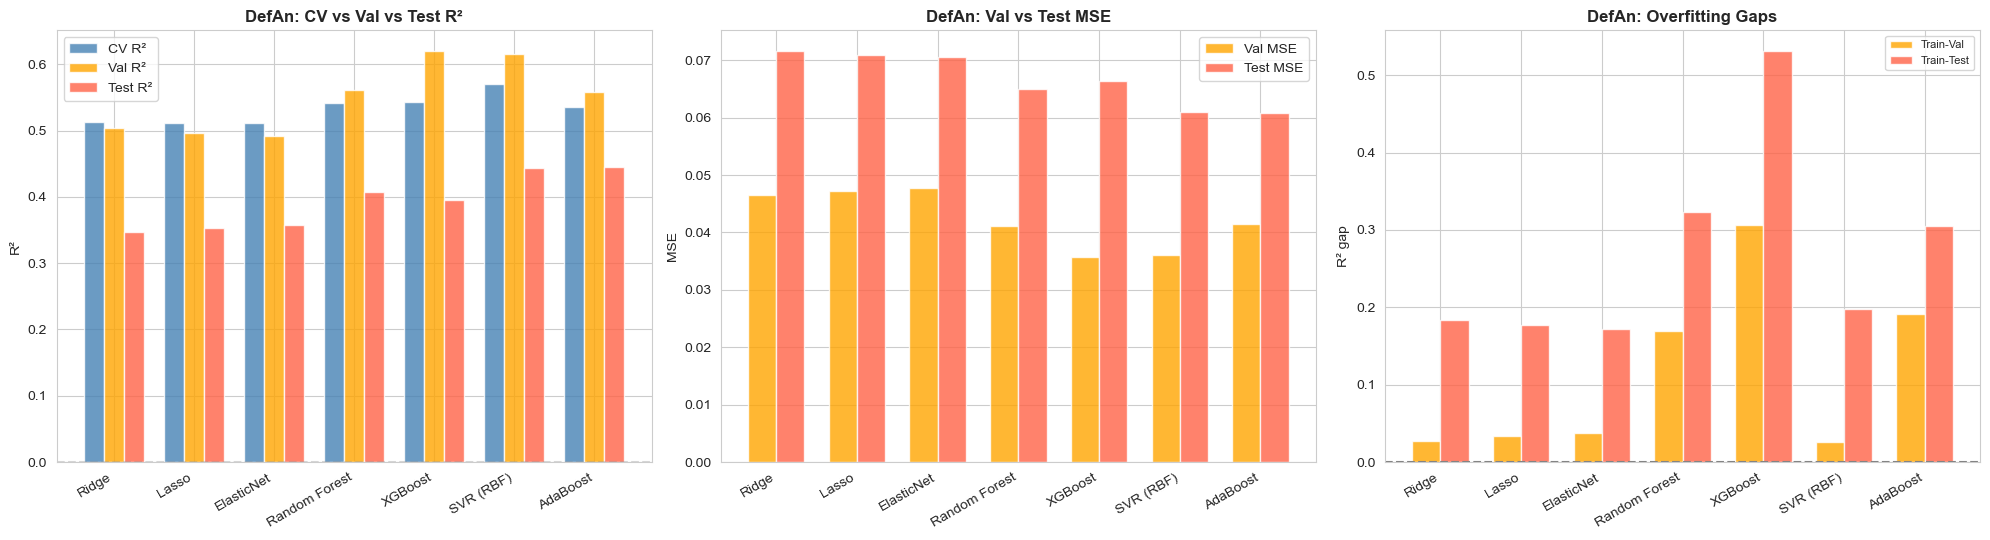

In [34]:
fig = plot_regression_results_bar(df_reg, title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_regression_results.png'), dpi=150, bbox_inches='tight')
plt.show()


###
This figure compares the regression models using **cross-validation (CV)**, **validation**, and **test** \(R^2\) scores.

- **CV \(R^2\)** is the average score obtained by cross-validation on the training data, giving an estimate of expected generalization during model development.
- **Validation \(R^2\)** measures performance on the held-out validation set used for model selection.
- **Test \(R^2\)** measures final performance on completely unseen data and is the strongest indicator of real predictive quality.

The figure therefore shows both overall model quality and whether a model’s performance remains stable from internal evaluation to truly unseen data.

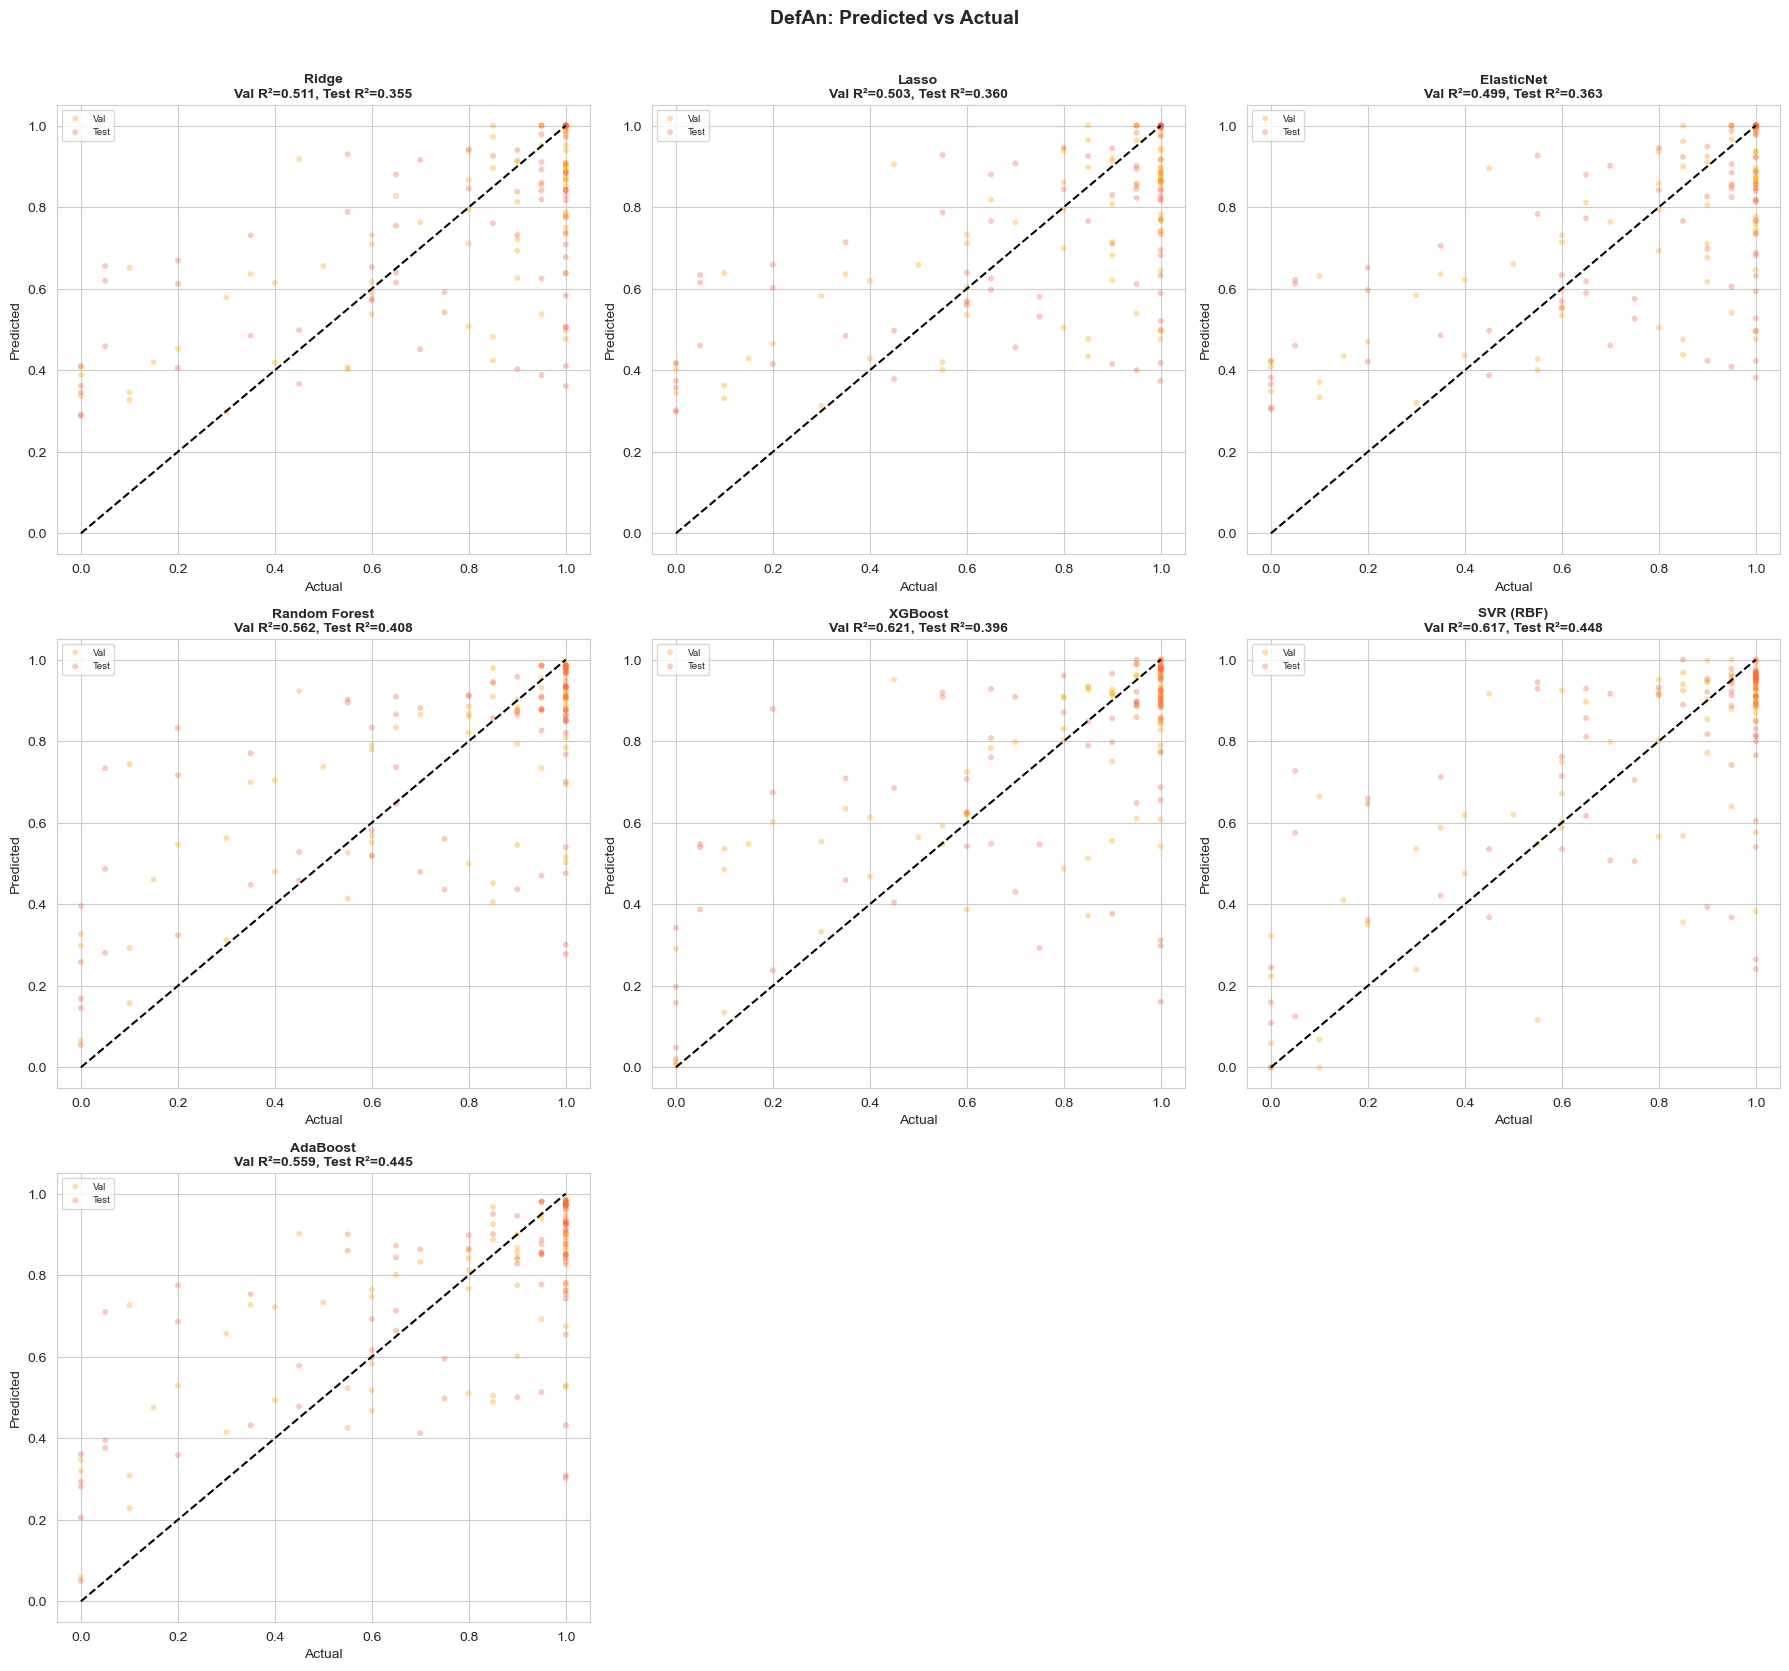

In [35]:
fig = plot_pred_vs_actual(fitted_regs, sp, title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_pred_vs_actual.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This figure compares predicted vs true hallucination probability for the regression models.

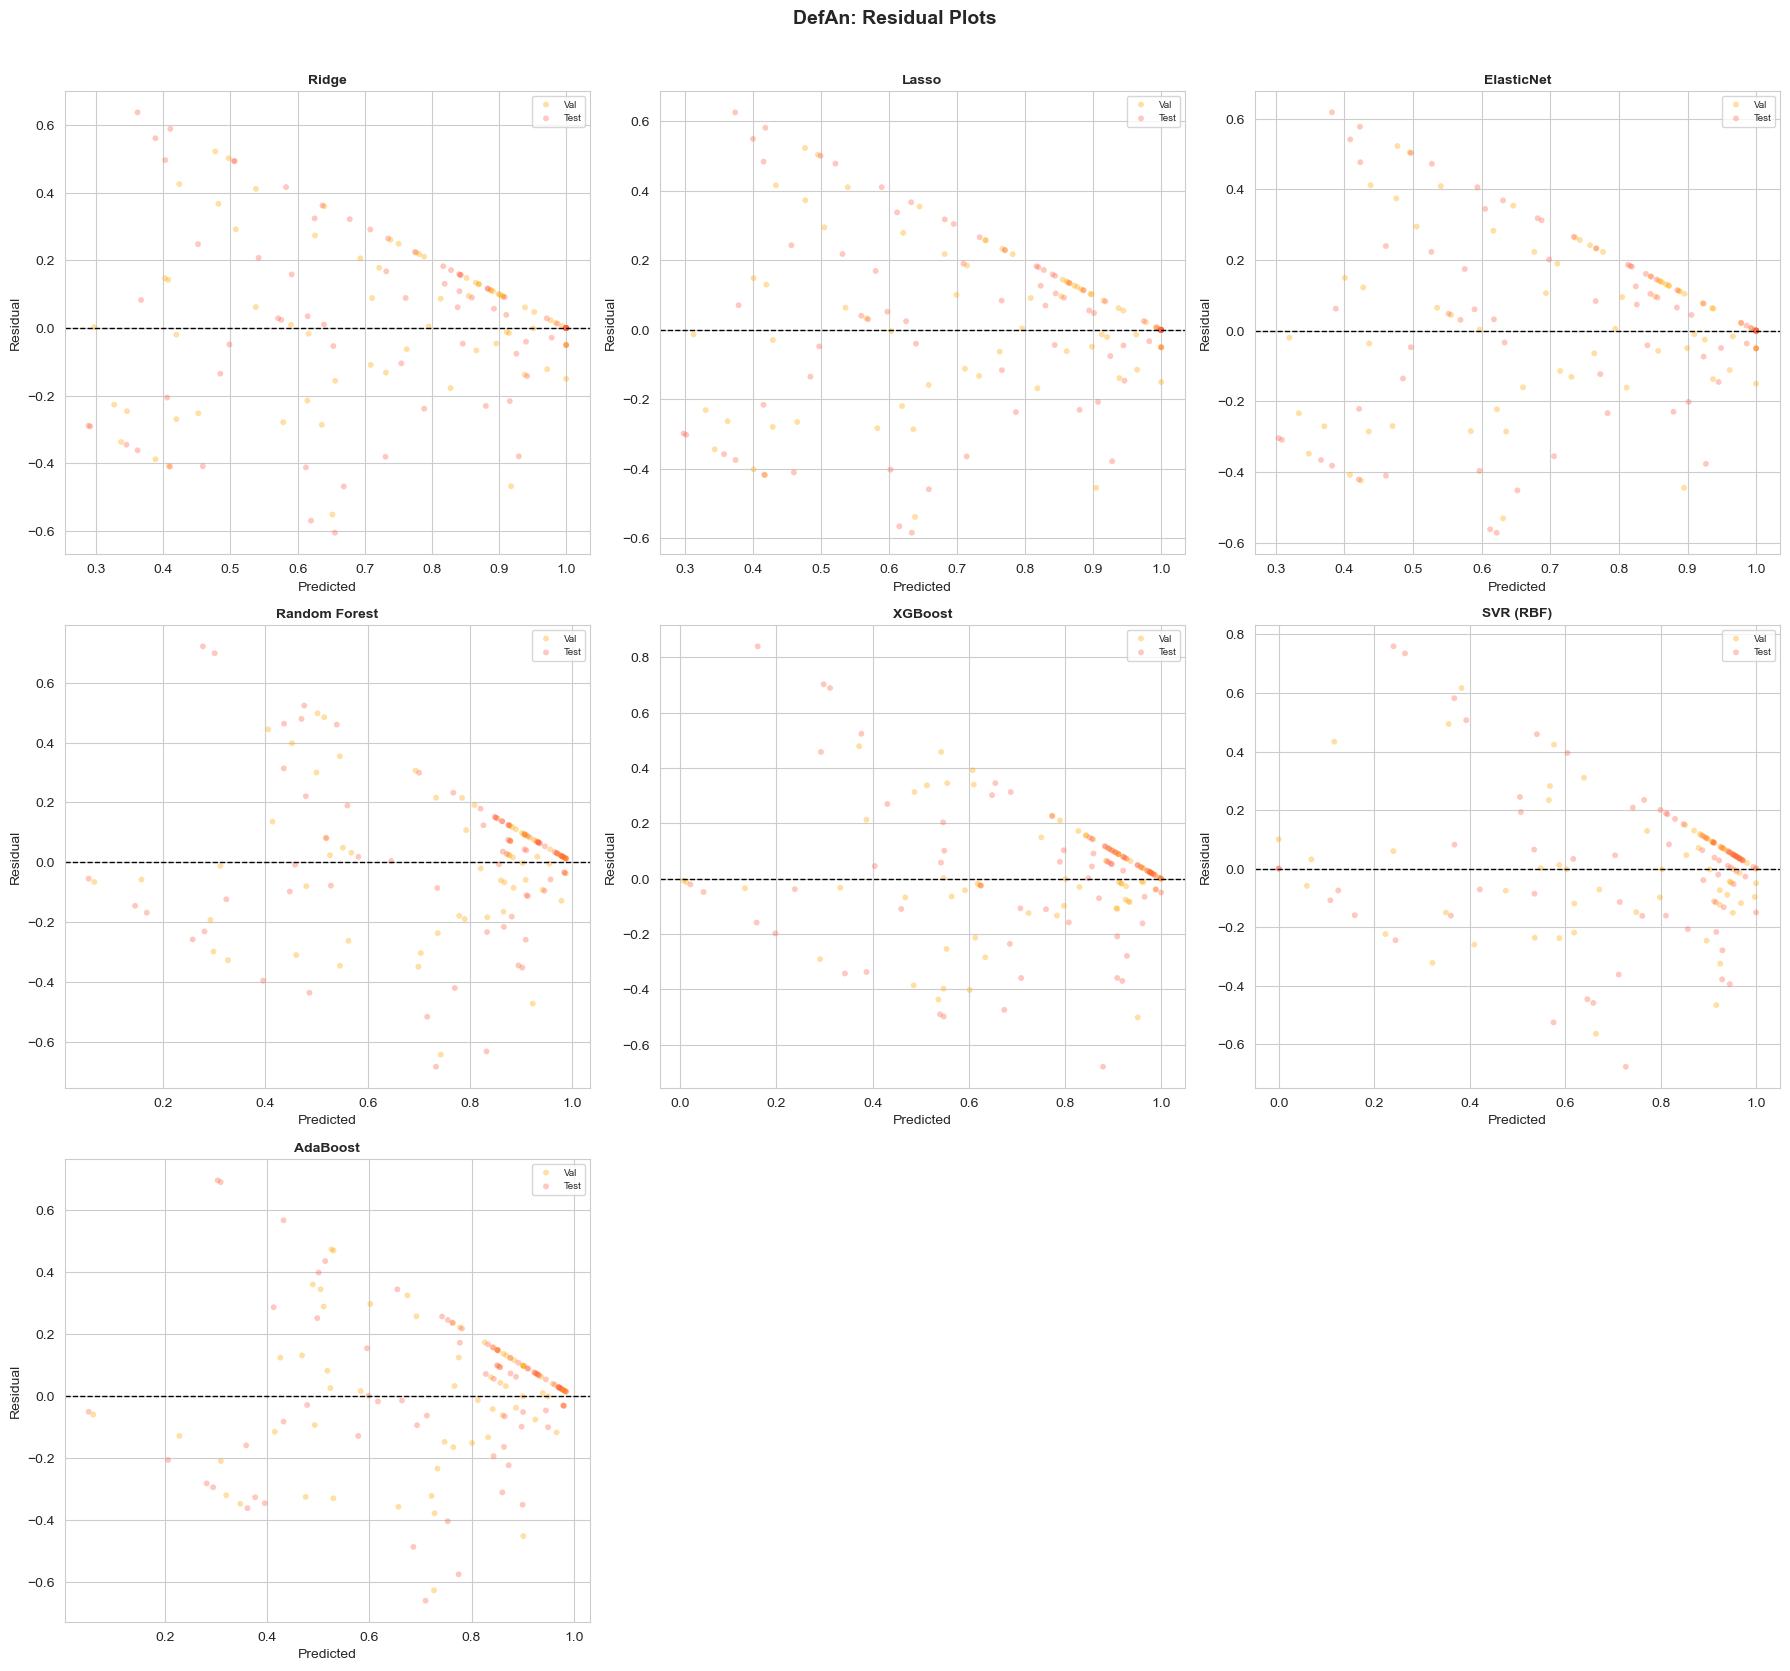

In [36]:
fig = plot_residuals(fitted_regs, sp, title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_residuals.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This is the residual analysis figure, showing the pattern of prediction errors.

## Ablation Study (Regression)

Ablation Val R²:


Model,AdaBoost,Random Forest,Ridge,XGBoost
Variant,,,,
All 5 + extended,0.5592,0.5616,0.5044,0.6203
All 5 geometric,0.5592,0.5616,0.5044,0.6203
Entropy + Geometry,0.4954,0.4896,0.4816,0.5222
Entropy only (H_sem),0.3430,0.3309,0.3977,0.1895
"Geometry (D_cos, M_bar)",0.4061,0.4004,0.3516,0.3518


Ablation Test R²:


Model,AdaBoost,Random Forest,Ridge,XGBoost
Variant,,,,
All 5 + extended,0.4454,0.4075,0.3475,0.3959
All 5 geometric,0.4454,0.4075,0.3475,0.3959
Entropy + Geometry,0.4702,0.4410,0.3493,0.3725
Entropy only (H_sem),0.1400,0.0996,0.2361,-0.0093
"Geometry (D_cos, M_bar)",0.4639,0.4569,0.3671,0.3014


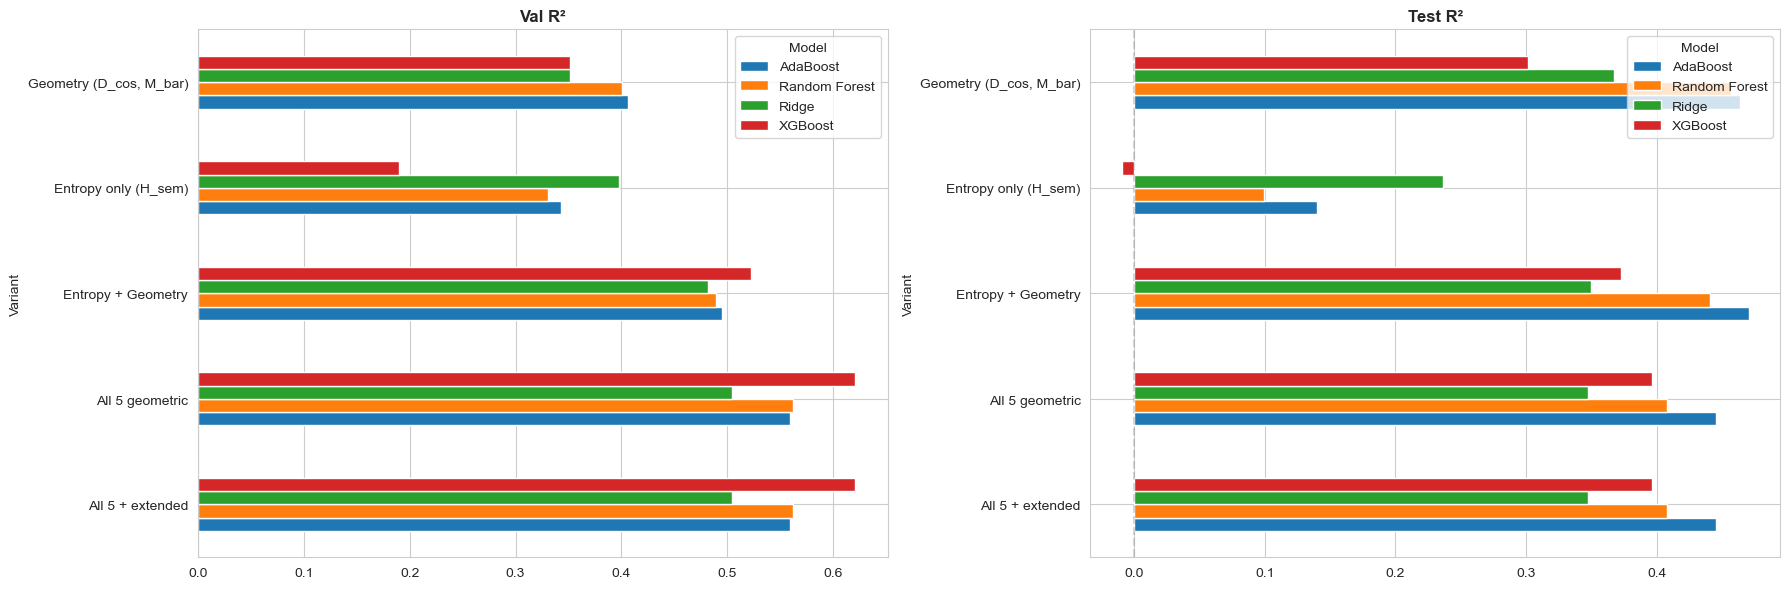

In [37]:
abl_models = {k: regressors[k] for k in ['Ridge', 'Random Forest', 'XGBoost', 'AdaBoost'] if k in regressors}
ext_feats = GEO_FEATURES #+ ['frac_refused', 'score_mean', 'len_mean']
# ensure columns exist
for c in ext_feats:
    if c not in sp['feat_train'].columns:
        ext_feats = GEO_FEATURES  # fallback
        break

df_abl = run_ablation(abl_models, sp, sp['feat_train'], sp['feat_val'], sp['feat_test'],
                       extended_features=ext_feats)
df_abl.to_csv(os.path.join(OUTPUT_DIR, 'ablation_regression.csv'), index=False)

pivot_val = df_abl.pivot_table(index='Variant', columns='Model', values='Val_R2')
pivot_test = df_abl.pivot_table(index='Variant', columns='Model', values='Test_R2')
print('Ablation Val R²:')
display(pivot_val.round(4))
print('Ablation Test R²:')
display(pivot_test.round(4))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
pivot_val.plot(kind='barh', ax=axes[0]); axes[0].set_title('Val R²', fontweight='bold')
pivot_test.plot(kind='barh', ax=axes[1]); axes[1].set_title('Test R²', fontweight='bold')
for ax in axes: ax.axvline(0, color='gray', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_ablation.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This figure summarizes the regression ablation study, comparing feature subsets across multiple regressors. It is especially useful because it tells you which parts of the feature set really carry predictive signal

## Binary vs Regression Comparison

Threshold regression predictions at 0.5, compare AUC/Accuracy/F1 against
direct classifiers (including AdaBoost).


In [38]:
classifiers = get_classifiers(seed=RANDOM_SEED)
df_compare = compare_regression_vs_classification(regressors, classifiers, sp)
df_compare.to_csv(os.path.join(OUTPUT_DIR, 'binary_vs_regression.csv'), index=False)

print('=== Val Set ===')
display(df_compare[df_compare['Split']=='Val'].drop(columns='Split').round(4))
print('\n=== Test Set ===')
display(df_compare[df_compare['Split']=='Test'].drop(columns='Split').round(4))


=== Val Set ===


,Model,Approach,AUC,Accuracy,F1
0,Logistic Regression,Classification,0.8756,0.8133,0.8852
2,Random Forest (cls),Classification,0.9067,0.8400,0.9016
4,XGBoost (cls),Classification,0.8967,0.8533,0.9076
6,AdaBoost (cls),Classification,0.8944,0.8400,0.9000
8,Ridge (reg->cls),Regression->Binary,0.8789,0.8400,0.9000
10,Lasso (reg->cls),Regression->Binary,0.8811,0.8400,0.9000
12,ElasticNet (reg->cls),Regression->Binary,0.8822,0.8400,0.9000
14,Random Forest (reg->cls),Regression->Binary,0.8711,0.8533,0.9106
16,XGBoost (reg->cls),Regression->Binary,0.8878,0.8533,0.9120
18,SVR (RBF) (reg->cls),Regression->Binary,0.9111,0.8800,0.9268



=== Test Set ===


,Model,Approach,AUC,Accuracy,F1
1,Logistic Regression,Classification,0.8978,0.8267,0.8926
3,Random Forest (cls),Classification,0.8800,0.8400,0.9016
5,XGBoost (cls),Classification,0.8844,0.8267,0.8908
7,AdaBoost (cls),Classification,0.9022,0.8267,0.8889
9,Ridge (reg->cls),Regression->Binary,0.8878,0.8667,0.9167
11,Lasso (reg->cls),Regression->Binary,0.8867,0.8533,0.9076
13,ElasticNet (reg->cls),Regression->Binary,0.8889,0.8533,0.9076
15,Random Forest (reg->cls),Regression->Binary,0.9044,0.8400,0.8983
17,XGBoost (reg->cls),Regression->Binary,0.8900,0.8400,0.9000
19,SVR (RBF) (reg->cls),Regression->Binary,0.9244,0.8667,0.9180


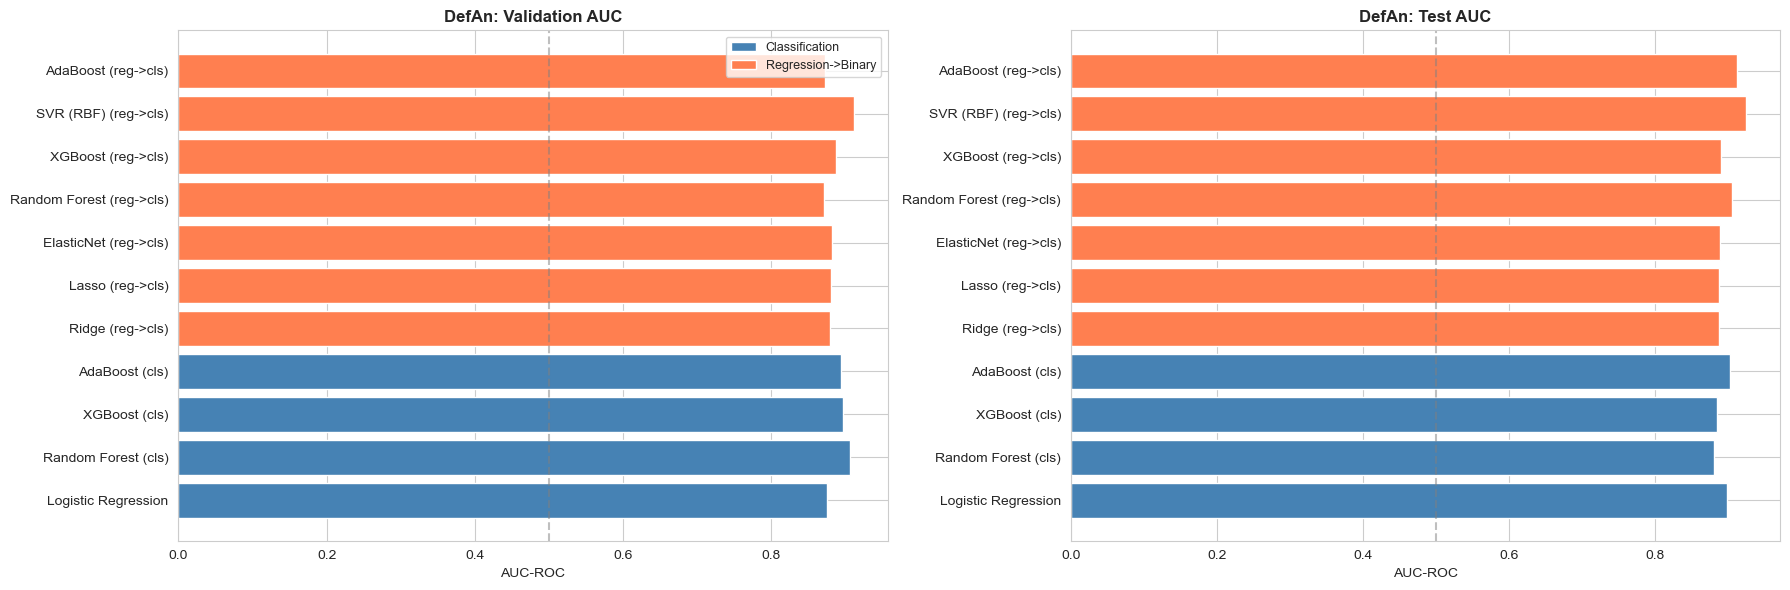

In [39]:
fig = plot_comparison_bar(df_compare, title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_cls_vs_reg.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This figure compares direct binary classification against regression followed by thresholding at 0.5. It is conceptually important because it asks whether modeling a continuous hallucination probability is actually useful even if the final downstream task is binary.

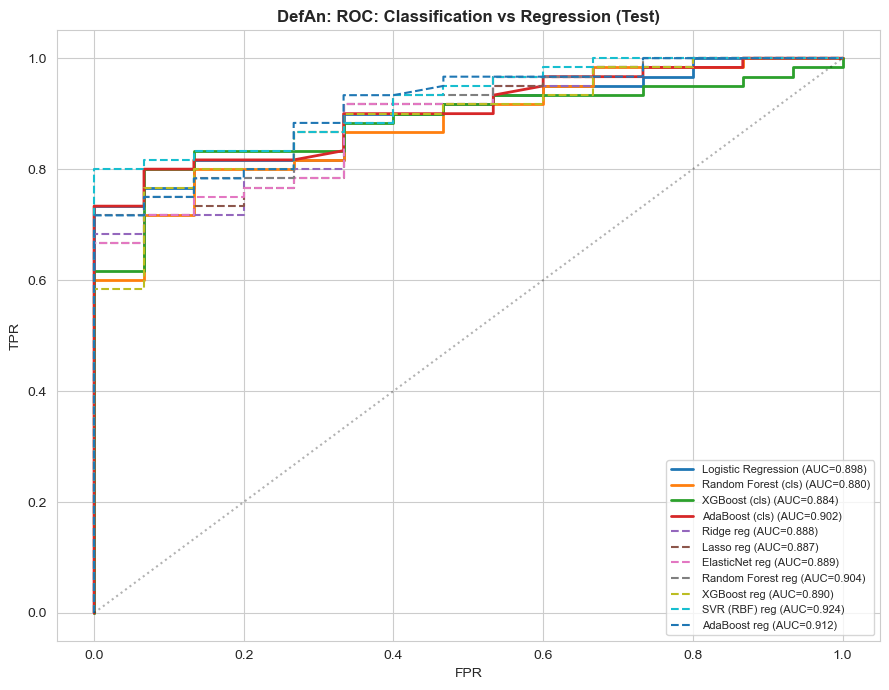

In [40]:
fig = plot_comparison_roc(regressors, classifiers, sp, title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_roc_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This ROC comparison plot gives a more visual version of the same binary-vs-regression story.

## Bootstrap Confidence Intervals

Best model (by Val R²): XGBoost
  R2: 0.3710  95% CI [-0.0208, 0.6377]
  MSE: 0.0661  95% CI [0.0394, 0.0962]
  MAE: 0.1754  95% CI [0.1353, 0.2193]


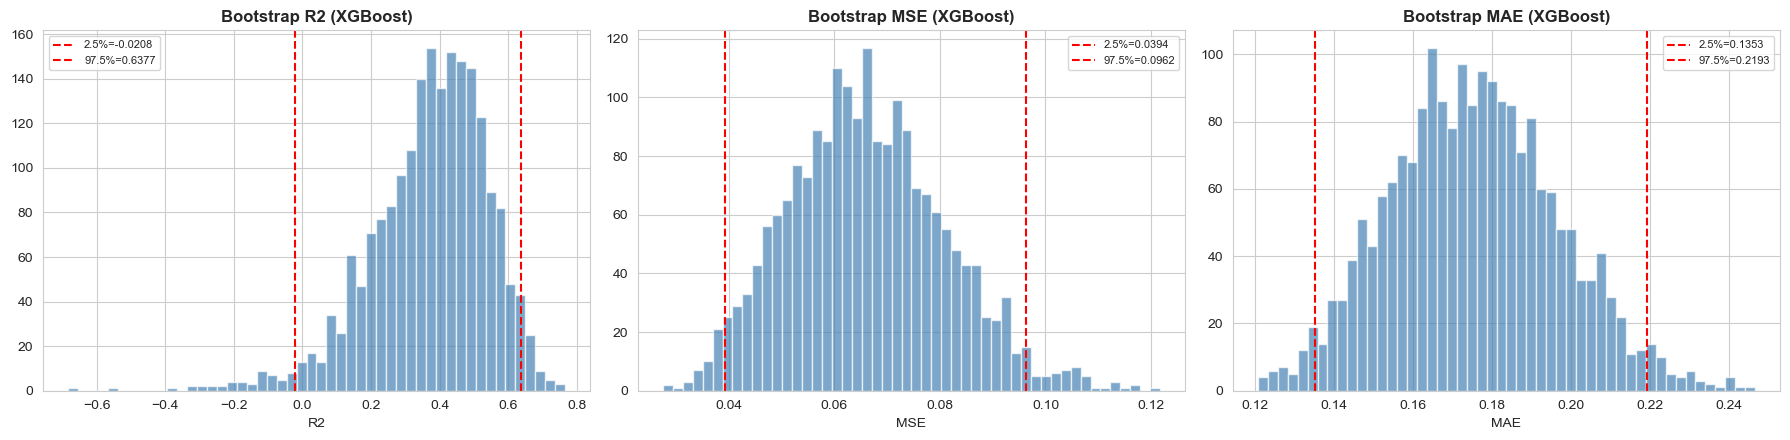

In [41]:
best_name = df_reg.loc[df_reg['Val_R2'].idxmax(), 'Model']
print(f'Best model (by Val R²): {best_name}')
best_reg = fitted_regs[best_name]
best_reg.fit(sp['X_train_sc'], sp['y_train_reg'])
test_preds = np.clip(best_reg.predict(sp['X_test_sc']), 0, 1)

boot = bootstrap_regression_ci(sp['y_test_reg'], test_preds, n_boot=N_BOOTSTRAP, seed=RANDOM_SEED)
for m in ['R2', 'MSE', 'MAE']:
    ci = boot[m]
    print(f'  {m}: {ci["mean"]:.4f}  95% CI [{ci["ci_lo"]:.4f}, {ci["ci_hi"]:.4f}]')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, m in zip(axes, ['R2', 'MSE', 'MAE']):
    vals = boot[m]['values']
    ax.hist(vals, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    ax.axvline(boot[m]['ci_lo'], color='red', linestyle='--', label=f'2.5%={boot[m]["ci_lo"]:.4f}')
    ax.axvline(boot[m]['ci_hi'], color='red', linestyle='--', label=f'97.5%={boot[m]["ci_hi"]:.4f}')
    ax.set_xlabel(m); ax.set_title(f'Bootstrap {m} ({best_name})', fontweight='bold')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_bootstrap_ci.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This figure shows bootstrap confidence intervals for the selected best validation model

## Calibration Analysis

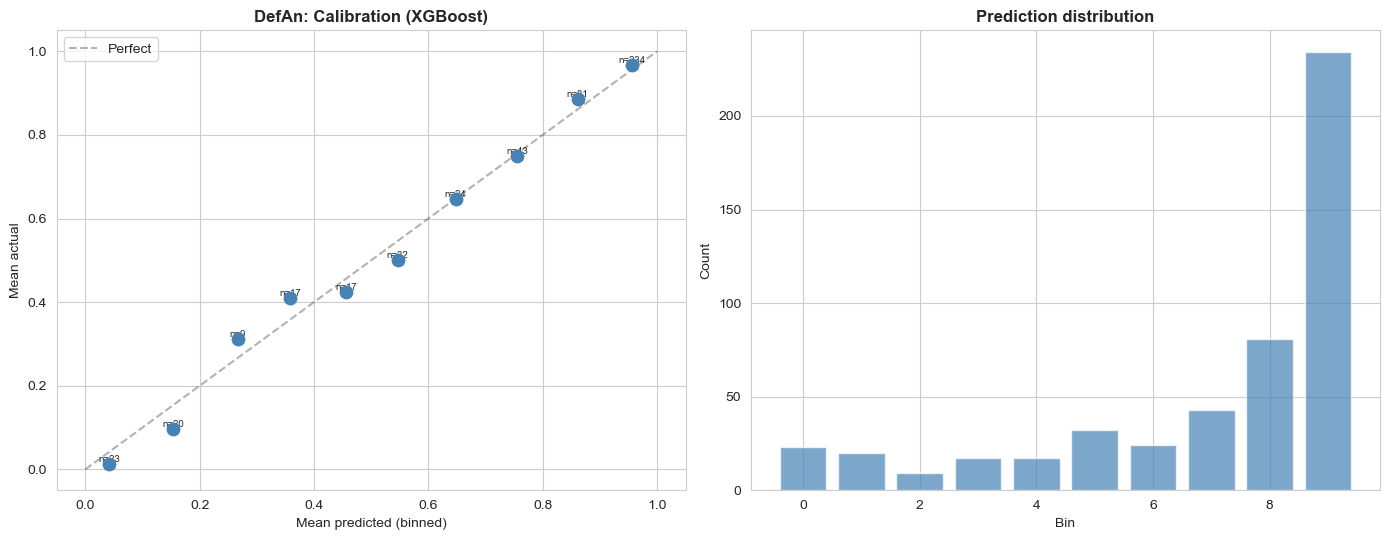

In [42]:
best_name = df_reg.loc[df_reg['Val_R2'].idxmax(), 'Model']
best_reg = fitted_regs[best_name]
sc_cal = StandardScaler().fit(sp['X_train'])
best_reg.fit(sc_cal.transform(sp['X_train']), sp['y_train_reg'])
X_all = feat_df[GEO_FEATURES].values
all_preds = np.clip(best_reg.predict(sc_cal.transform(X_all)), 0, 1)
y_all = feat_df['p_halluc'].values

fig = plot_calibration(y_all, all_preds, model_name=best_name, title_prefix='DefAn: ')
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_calibration.png'), dpi=150, bbox_inches='tight')
plt.show()


#### This is the calibration figure for the regression predictions.

## Learning Curves

In [49]:
# lc_models = {k: regressors[k] for k in ['Ridge', 'Random Forest', 'XGBoost'] if k in regressors}
# fig = plot_learning_curves(lc_models, sp, title_prefix='DefAn: ')
# plt.savefig(os.path.join(OUTPUT_DIR, 'fig_learning_curves.png'), dpi=150, bbox_inches='tight')
# plt.show()


## Feature Importance + SHAP

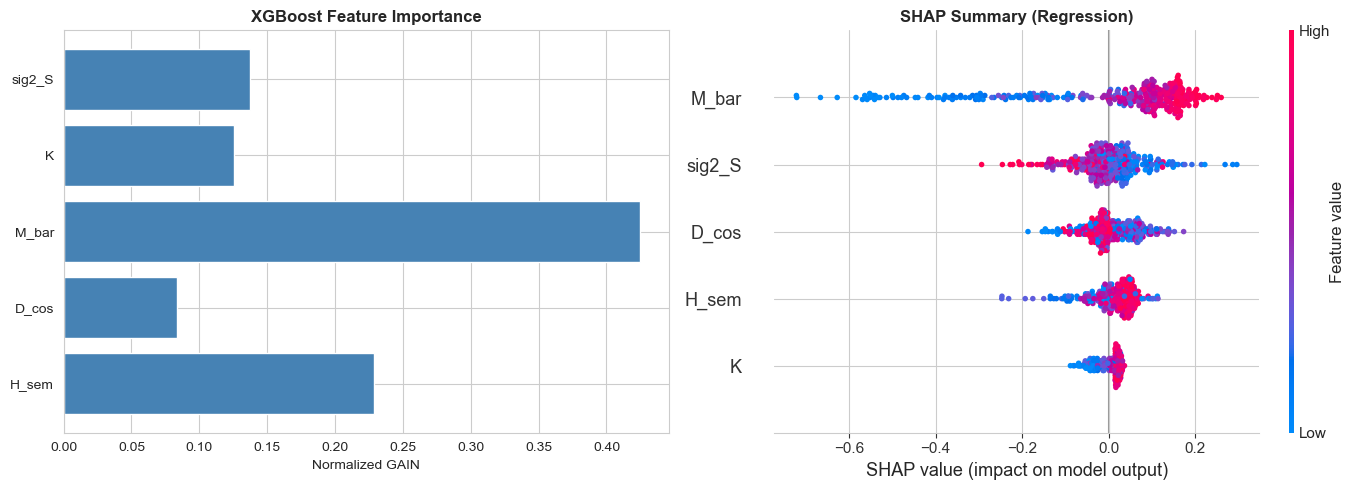

In [44]:
xgb_reg = xgb.XGBRegressor(n_estimators=350, max_depth=4, learning_rate=0.08,
    subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
    random_state=RANDOM_SEED, verbosity=0)
xgb_reg.fit(sp['X_train_sc'], sp['y_train_reg'])

explainer = shap.TreeExplainer(xgb_reg)
sv = explainer.shap_values(sp['X_train_sc'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
booster = xgb_reg.get_booster()
gain_dict = booster.get_score(importance_type='gain')
gains = np.array([gain_dict.get(f'f{i}', 0.0) for i in range(len(GEO_FEATURES))], dtype=float)
total = gains.sum()
gains_norm = gains / total if total > 0 else gains
axes[0].barh(GEO_FEATURES, gains_norm, color='steelblue')
axes[0].set_xlabel('Normalized GAIN'); axes[0].set_title('XGBoost Feature Importance', fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(sv, sp['X_train_sc'], feature_names=GEO_FEATURES, show=False, plot_size=None)
axes[1].set_title('SHAP Summary (Regression)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig_shap.png'), dpi=150, bbox_inches='tight')
plt.show()


## Cross-Dataset Generalization

Train on DefAn, predict on: MMLU, TriviaQA, TruthfulQA.
Both regression and classification models are compared.


### DefAn → MMLU

MMLU loaded: 500 questions, label rate=0.784


,Model,Approach,MMLU_AUC,MMLU_Acc,MMLU_F1,MMLU_R2
0,Ridge,Regression,0.6682,0.786,0.8799,0.1026
1,Lasso,Regression,0.6954,0.786,0.8799,0.1222
2,ElasticNet,Regression,0.7100,0.786,0.8799,0.1375
3,Random Forest,Regression,0.8778,0.796,0.8844,0.4537
4,XGBoost,Regression,0.8616,0.798,0.8856,0.3721
5,SVR (RBF),Regression,0.7505,0.786,0.8799,-0.1312
6,AdaBoost,Regression,0.8740,0.788,0.8806,0.3812
7,Logistic Regression,Classification,0.7742,0.788,0.8795,NaN
8,Random Forest (cls),Classification,0.8664,0.804,0.8876,NaN
9,XGBoost (cls),Classification,0.6634,0.776,0.8713,NaN


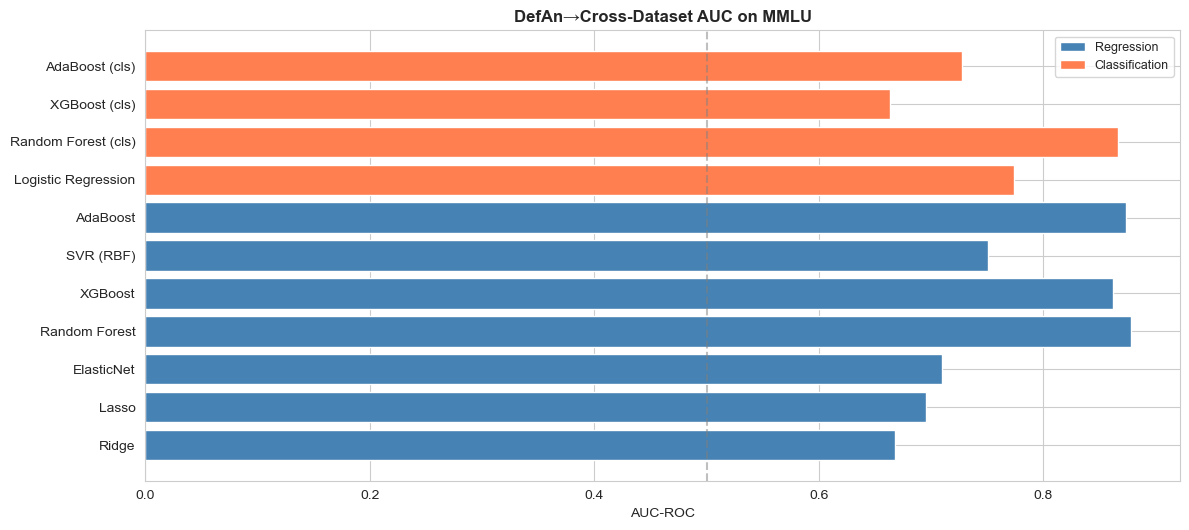

In [45]:
# Load target features
tgt_path = 'mmlu_output/mmlu_features.csv'
if os.path.exists(tgt_path):
    tgt_df = pd.read_csv(tgt_path)
    print(f'MMLU loaded: {len(tgt_df)} questions, label rate={tgt_df["label"].mean():.3f}')

    df_xd = evaluate_cross_dataset(regressors, classifiers, sp, tgt_df, 'MMLU')
    df_xd.to_csv(os.path.join(OUTPUT_DIR, 'cross_dataset_to_mmlu.csv'), index=False)
    display(df_xd.round(4))

    fig = plot_cross_dataset_summary(df_xd, 'MMLU', title_prefix='DefAn→')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_xd_mmlu.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'WARNING: {tgt_path} not found. Run the MMLU classification pipeline first.')


#### This figure summarizes cross-dataset transfer from DefAn to MMLU. It tests whether a model trained on DefAn learns something general about hallucination geometry rather than just overfitting one benchmark. The strongest result here is that Random Forest regression and AdaBoost regression transfer quite well, with AUCs around 0.87–0.88, while linear models transfer only modestly. This makes the figure important for the claim of out-of-dataset robustness.

### DefAn → TriviaQA

TriviaQA loaded: 500 questions, label rate=0.416


,Model,Approach,TriviaQA_AUC,TriviaQA_Acc,TriviaQA_F1,TriviaQA_R2
0,Ridge,Regression,0.9561,0.858,0.8518,0.4139
1,Lasso,Regression,0.9586,0.848,0.8430,0.3984
2,ElasticNet,Regression,0.9597,0.846,0.8412,0.3880
3,Random Forest,Regression,0.9485,0.768,0.7795,0.3126
4,XGBoost,Regression,0.9046,0.600,0.6689,0.1820
5,SVR (RBF),Regression,0.9295,0.858,0.8440,0.5295
6,AdaBoost,Regression,0.9543,0.578,0.6613,0.2704
7,Logistic Regression,Classification,0.9409,0.628,0.6858,NaN
8,Random Forest (cls),Classification,0.9013,0.586,0.6533,NaN
9,XGBoost (cls),Classification,0.8261,0.590,0.6543,NaN


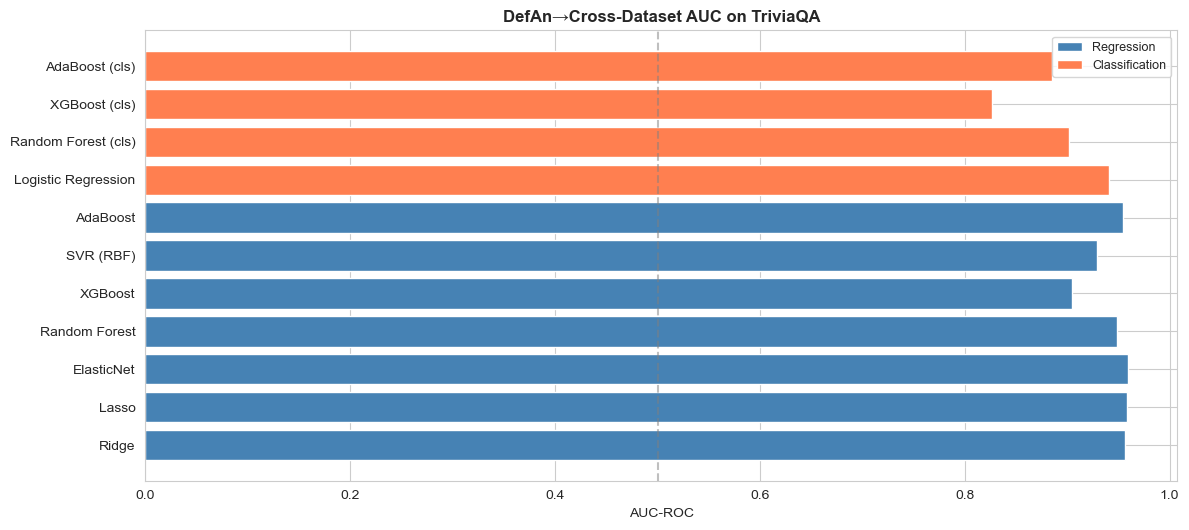

In [46]:
# Load target features
tgt_path = 'triviaqa_output/triviaqa_features.csv'
if os.path.exists(tgt_path):
    tgt_df = pd.read_csv(tgt_path)
    print(f'TriviaQA loaded: {len(tgt_df)} questions, label rate={tgt_df["label"].mean():.3f}')

    df_xd = evaluate_cross_dataset(regressors, classifiers, sp, tgt_df, 'TriviaQA')
    df_xd.to_csv(os.path.join(OUTPUT_DIR, 'cross_dataset_to_triviaqa.csv'), index=False)
    display(df_xd.round(4))

    fig = plot_cross_dataset_summary(df_xd, 'TriviaQA', title_prefix='DefAn→')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_xd_triviaqa.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'WARNING: {tgt_path} not found. Run the TriviaQA classification pipeline first.')


### DefAn → TruthfulQA

TruthfulQA loaded: 500 questions, label rate=0.720


,Model,Approach,TruthfulQA_AUC,TruthfulQA_Acc,TruthfulQA_F1,TruthfulQA_R2
0,Ridge,Regression,0.8959,0.828,0.8847,0.4813
1,Lasso,Regression,0.8982,0.826,0.8835,0.4844
2,ElasticNet,Regression,0.8997,0.826,0.8835,0.4858
3,Random Forest,Regression,0.8958,0.826,0.8854,0.3989
4,XGBoost,Regression,0.8600,0.808,0.8743,0.2978
5,SVR (RBF),Regression,0.8759,0.828,0.8850,0.2937
6,AdaBoost,Regression,0.9072,0.814,0.8791,0.4209
7,Logistic Regression,Classification,0.9015,0.836,0.8889,NaN
8,Random Forest (cls),Classification,0.8897,0.822,0.8815,NaN
9,XGBoost (cls),Classification,0.8930,0.826,0.8826,NaN


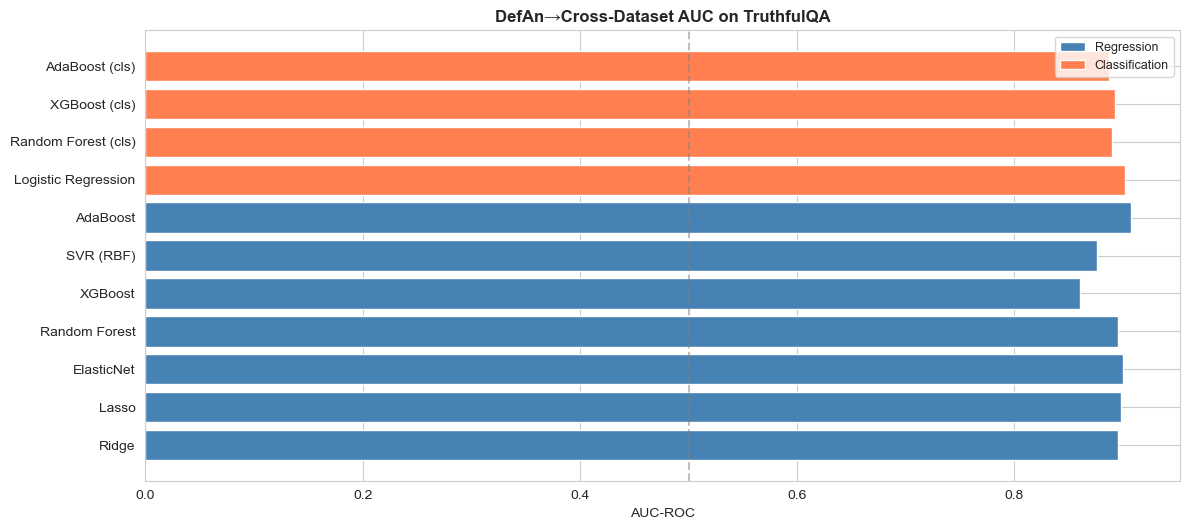

In [47]:
# Load target features
tgt_path = 'truthfulqa_output/truthfulqa_features.csv'
if os.path.exists(tgt_path):
    tgt_df = pd.read_csv(tgt_path)
    print(f'TruthfulQA loaded: {len(tgt_df)} questions, label rate={tgt_df["label"].mean():.3f}')

    df_xd = evaluate_cross_dataset(regressors, classifiers, sp, tgt_df, 'TruthfulQA')
    df_xd.to_csv(os.path.join(OUTPUT_DIR, 'cross_dataset_to_truthfulqa.csv'), index=False)
    display(df_xd.round(4))

    fig = plot_cross_dataset_summary(df_xd, 'TruthfulQA', title_prefix='DefAn→')
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig_xd_truthfulqa.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'WARNING: {tgt_path} not found. Run the TruthfulQA classification pipeline first.')


## Summary

In [48]:
print('=' * 76)
print('DEFAN REGRESSION PIPELINE SUMMARY')
print('=' * 76)
print(f'Questions analyzed: {len(feat_df)}')
print(f'Split: Train={len(sp["X_train"])} / Val={len(sp["X_val"])} / Test={len(sp["X_test"])}')
print(f'Target p_halluc: mean={feat_df["p_halluc"].mean():.4f}, std={feat_df["p_halluc"].std():.4f}')
print()

best = df_reg.loc[df_reg['Val_R2'].idxmax()]
print(f'Best regression model (by Val R²): {best["Model"]}')
print(f'  CV R²={best["CV_R2"]:.4f}  Val R²={best["Val_R2"]:.4f}  Test R²={best["Test_R2"]:.4f}')
print(f'  Overfit gap: {best["Overfit_Gap_Val"]:+.4f}')
print()

best_clf = df_compare[df_compare['Split']=='Test'].sort_values('AUC', ascending=False).iloc[0]
print(f'Best binary model (Test AUC): {best_clf["Model"]} ({best_clf["Approach"]})')
print(f'  AUC={best_clf["AUC"]:.4f}  Acc={best_clf["Accuracy"]:.4f}  F1={best_clf["F1"]:.4f}')
print()

print('Cross-dataset targets: MMLU, TriviaQA, TruthfulQA')
print(f'Outputs: {OUTPUT_DIR}/')
print('=' * 76)


DEFAN REGRESSION PIPELINE SUMMARY
Questions analyzed: 500
Split: Train=350 / Val=75 / Test=75
Target p_halluc: mean=0.7623, std=0.3216

Best regression model (by Val R²): XGBoost
  CV R²=0.5434  Val R²=0.6203  Test R²=0.3959
  Overfit gap: +0.3068

Best binary model (Test AUC): SVR (RBF) (reg->cls) (Regression->Binary)
  AUC=0.9244  Acc=0.8667  F1=0.9180

Cross-dataset targets: MMLU, TriviaQA, TruthfulQA
Outputs: defan_regression_output/
